# Импорт библиотек

In [1]:
from typing import Dict
import matplotlib.pyplot as plt
from math import ceil, nan

In [2]:
from library import Ra40, d_cuff
from utils import choice

# Исходные данные

In [3]:
n = 6  # количество участков

moment = 346.91  # Н*м
sigma = 110 * 10**6  # Па 100..120

# Размеры муфты
d_connection = 45
l_conection = 50

assert d_connection in Ra40

l_bearing = 21

ГОСТ 6636–69: 20; 22; 24; 25; 26;28; 30; 32; 34; (35); 36; 38; 40; 42; 45; 48; 50; 53; (55); 56; 60; 63; (65); 67;(70); 71; 75; 80; 85; 90; 95; 100. 

d | 17..22 | 24..30 | 32..38 | 40..44 | 45..50 | 52..58 | 60..65 | 67..75 | 80..85 | 90..95
---|---|---|---|---|---|---|---|---|---|---
r | 1.5 | 2.0 | 2.5 | 2.5 | 3.0 | 3.0 | 3.5 | 3.5 | 3.7 | 4.0
f | 1.0 | 1.0 | 1.2 | 1.2 | 1.6 | 2.0 | 2.0 | 2.5 | 2.5 | 3.0

In [4]:
def getF(d: float) -> float:
    if 17 <= d <= 22:
        return 1.0
    if 24 <= d <= 30:
        return 1.0
    if 32 <= d <= 38:
        return 1.2
    if 40 <= d <= 44:
        return 1.2
    if 45 <= d <= 50:
        return 1.6
    if 52 <= d <= 58:
        return 2.0
    if 60 <= d <= 65:
        return 2.0
    if 67 <= d <= 75:
        return 2.5
    if 80 <= d <= 85:
        return 2.5
    if 90 <= d <= 95:
        return 3.0
    return nan


def get_spline(d: float) -> Dict[str, float]:
    if 12 <= d < 17:
        return {"b": 5.0, "h": 5, "t1": 3.0, "l_min": 10, "l_max": 56}
    if 17 <= d < 22:
        return {"b": 6.0, "h": 6, "t1": 3.5, "l_min": 14, "l_max": 70}
    if 22 <= d < 30:
        return {"b": 8.0, "h": 7, "t1": 4.0, "l_min": 18, "l_max": 90}
    if 30 <= d < 38:
        return {"b": 10.0, "h": 8, "t1": 5.0, "l_min": 28, "l_max": 110}
    if 38 <= d < 44:
        return {"b": 12.0, "h": 8, "t1": 5.0, "l_min": 28, "l_max": 140}
    if 44 <= d < 50:
        return {"b": 14.0, "h": 9, "t1": 5.5, "l_min": 36, "l_max": 160}
    if 50 <= d < 58:
        return {"b": 16.0, "h": 10, "t1": 6.0, "l_min": 45, "l_max": 180}
    if 58 <= d < 65:
        return {"b": 18.0, "h": 11, "t1": 7.0, "l_min": 50, "l_max": 200}
    if 65 <= d < 75:
        return {"b": 20.0, "h": 12, "t1": 7.5, "l_min": 56, "l_max": 220}
    if 75 <= d < 85:
        return {"b": 22.0, "h": 14, "t1": 9.0, "l_min": 63, "l_max": 250}
    if 85 <= d < 95:
        return {"b": 25.0, "h": 14, "t1": 9.0, "l_min": 70, "l_max": 280}
    return {}

## Расчет

Диаметры

In [5]:
# Инициализация
d = [nan] * (n + 1)

# диаметр муфты
d[0] = d_connection

# диаметр манжеты
f = getF(d[0])
d[1] = d[0] + 3 * f
d[1] = choice(d[1], d_cuff, "ceil")

# диаметр подшипника
d[2] = int(ceil(d[1]))
while True:
    d[2] += 1
    if d[2] % 5 == 0:
        break

# диаметр ступицы
f = getF(d[2])
d[3] = d[2] + 3 * f
d[3] = choice(d[3], Ra40, "nearest")

# диаметр упора колеса
f = getF(d[3])
d[4] = d[3] + 3 * f
d[4] = choice(d[4], Ra40, "nearest")

# диаметр подшипника
d[5] = d[4]

d[6] = d[2]

Длины

In [6]:
# Инициализацияы
l = [nan] * n

# длина посадки муфты
l[0] = l_conection

# длина ступицы
spline = get_spline(d[3])
l[3] = (2 * moment) / (d[3] / 1000 * (spline["h"] - spline["t1"]) / 1000 * sigma)
l[3] *= 1000  # мм
l[3] += spline["b"]
l_spline = choice(l[3], list(range(spline["l_min"], spline["l_max"], 1)), "ceil")
l[3] = l_spline + 6

# длина упора колеса
l[4] = 8

# длина подшипника
l[5] = l_bearing

l[2] = l[4] + l_bearing + 1

thin = max(1.35 * (moment) ** (1 / 4), 6)
l[1] = 6 + 10 + thin + 5

# Результат

In [7]:
print(d)
print(l)

[45, 50, 55, 60, 65, 65, 55]
[50, 27, 30, 56, 8, 21]


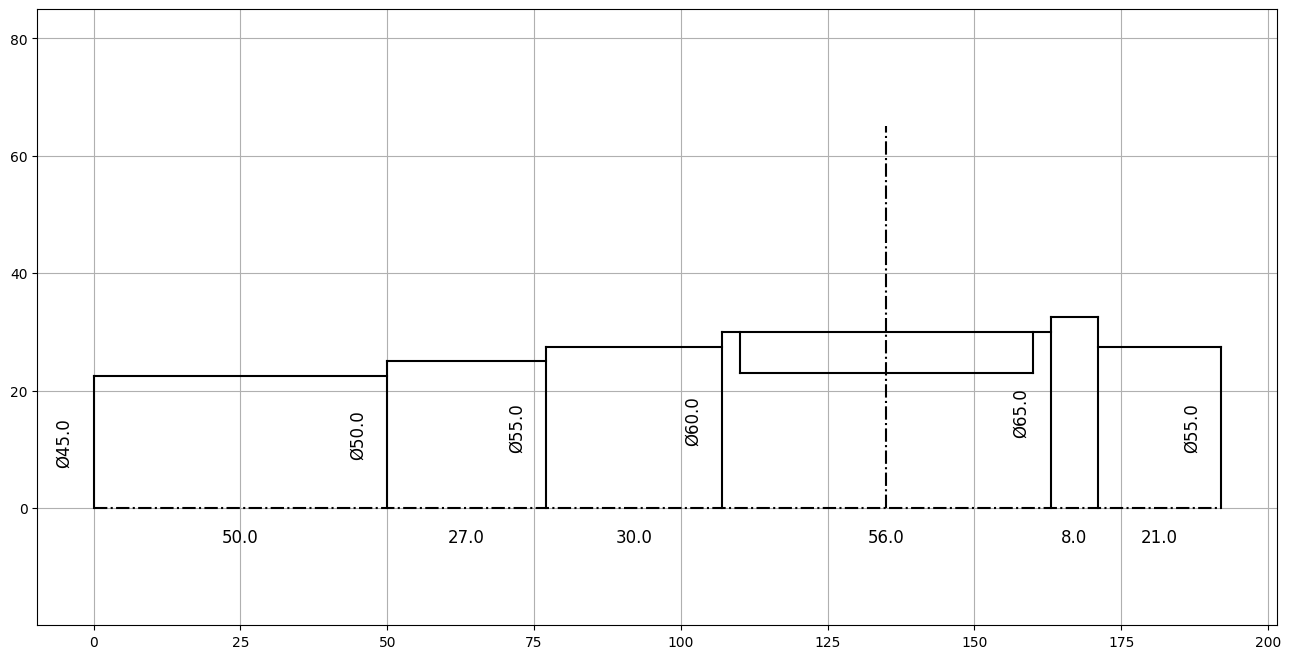

In [8]:
offset = 5


plt.figure(figsize=(16, 8))
plt.axis("equal")
plt.grid(True)

plt.plot([0, sum(l)], [0] * 2, color="black", ls="dashdot")  # ось
plt.plot([l[0] + l[1] + l[2] + l[3] / 2] * 2, [0, d[4]], color="black", ls="dashdot")  # ось колеса

# диаметры
plt.plot(2 * [0], [0, d[0] / 2], color="black", ls="solid")
plt.plot(2 * [l[0]], [0, d[1] / 2], color="black", ls="solid")
plt.plot(2 * [l[0] + l[1]], [0, d[2] / 2], color="black", ls="solid")
plt.plot(2 * [l[0] + l[1] + l[2]], [0, d[3] / 2], color="black", ls="solid")
plt.plot(2 * [l[0] + l[1] + l[2] + l[3]], [0, d[4] / 2], color="black", ls="solid")
plt.plot(2 * [l[0] + l[1] + l[2] + l[3] + l[4]], [0, d[5] / 2], color="black", ls="solid")
plt.plot(2 * [l[0] + l[1] + l[2] + l[3] + l[4] + l[5]], [0, d[6] / 2], color="black", ls="solid")

# линейные участки
plt.plot([0, l[0]], [d[0] / 2] * 2, color="black", ls="solid")
plt.plot([l[0], l[0] + l[1]], [d[1] / 2] * 2, color="black", ls="solid")
plt.plot([l[0] + l[1], l[0] + l[1] + l[2]], [d[2] / 2] * 2, color="black", ls="solid")
plt.plot([l[0] + l[1] + l[2], l[0] + l[1] + l[2] + l[3]], [d[3] / 2] * 2, color="black", ls="solid")
plt.plot([l[0] + l[1] + l[2] + l[3], l[0] + l[1] + l[2] + l[3] + l[4]], [d[4] / 2] * 2, color="black", ls="solid")
plt.plot([l[0] + l[1] + l[2] + l[3] + l[4], l[0] + l[1] + l[2] + l[3] + l[4] + l[5]], [d[6] / 2] * 2, color="black", ls="solid")

# диаметральные размеры
plt.text(0 - offset, d[0] / 4, f"Ø{d[0]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
plt.text(0 + l[0] - offset, d[1] / 4, f"Ø{d[1]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
plt.text(0 + l[0] + l[1] - offset, d[2] / 4, f"Ø{d[2]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
plt.text(0 + l[0] + l[1] + l[2] - offset, d[3] / 4, f"Ø{d[3]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
plt.text(0 + l[0] + l[1] + l[2] + l[3] - offset, d[4] / 4, f"Ø{d[4]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)
plt.text(0 + l[0] + l[1] + l[2] + l[3] + l[4] + l[5] - offset, d[6] / 4, f"Ø{d[6]:.1f}", color="black", fontsize=12, ha="center", va="center", rotation=90)

# линейные размеры
plt.text(l[0] / 2, -offset, f"{l[0]:.1f}", color="black", fontsize=12, ha="center", va="center")
plt.text(l[0] + l[1] / 2, -offset, f"{l[1]:.1f}", color="black", fontsize=12, ha="center", va="center")
plt.text(l[0] + l[1] + l[2] / 2, -offset, f"{l[2]:.1f}", color="black", fontsize=12, ha="center", va="center")
plt.text(l[0] + l[1] + l[2] + l[3] / 2, -offset, f"{l[3]:.1f}", color="black", fontsize=12, ha="center", va="center")
plt.text(l[0] + l[1] + l[2] + l[3] + l[4] / 2, -offset, f"{l[4]:.1f}", color="black", fontsize=12, ha="center", va="center")
plt.text(l[0] + l[1] + l[2] + l[3] + l[4] + l[5] / 2, -offset, f"{l[5]:.1f}", color="black", fontsize=12, ha="center", va="center")

# шпонка
plt.plot(2 * [l[0] + l[1] + l[2] + l[3] / 2 - l_spline / 2], [d[3] / 2, d[3] / 2 - spline["t1"]], color="black", ls="solid")
plt.plot([l[0] + l[1] + l[2] + l[3] / 2 - l_spline / 2, l[0] + l[1] + l[2] + l[3] / 2 + l_spline / 2], [d[3] / 2 - spline["t1"]] * 2, color="black", ls="solid")
plt.plot(2 * [l[0] + l[1] + l[2] + l[3] / 2 + l_spline / 2], [d[3] / 2, d[3] / 2 - spline["t1"]], color="black", ls="solid")

plt.show()